# DBSCAN Clustering for Typhoon Impact Profiling

## Overview
This notebook implements **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** to classify typhoon impact events in the Philippines. Unlike centroid-based methods like KMeans, DBSCAN is a **density-based clustering algorithm** that can discover clusters of arbitrary shapes and automatically identify noise/outlier points that don't belong to any cluster.

---

## Pipeline Architecture

```
┌─────────────────────────────────────────────────────────────────────────────────┐
│                         DBSCAN CLUSTERING PIPELINE                              │
├─────────────────────────────────────────────────────────────────────────────────┤
│                                                                                 │
│  ┌─────────────┐    ┌──────────────┐    ┌─────────────┐    ┌─────────────────┐  │
│  │   INPUT     │───▶│   PREPROCESS │───▶│     PCA     │───▶│     OPTUNA      │  │
│  │   DATA      │    │   & SCALE    │    │  REDUCTION  │    │  OPTIMIZATION   │  │
│  └─────────────┘    └──────────────┘    └─────────────┘    └────────┬────────┘  │
│                                                                      │          │
│                                    ┌─────────────────────────────────┘          │
│                                    ▼                                            │
│                     ┌──────────────────────────────────┐                        │
│                     │       DBSCAN PARAMETERS          │                        │
│                     │  ┌────────────┐  ┌────────────┐  │                        │
│                     │  │    eps     │  │ min_samples│  │                        │
│                     │  │ (radius)   │  │ (density)  │  │                        │
│                     │  └────────────┘  └────────────┘  │                        │
│                     └──────────────────────────────────┘                        │
│                                    │                                            │
│                                    ▼                                            │
│  ┌─────────────┐    ┌──────────────┐    ┌─────────────┐    ┌─────────────────┐  │
│  │   OUTPUT    │◀───│    NOISE     │◀───│  METRICS    │◀───│  VISUALIZATION  │  │
│  │   RESULTS   │    │  DETECTION   │    │  EVALUATION │    │   2D & 3D PCA   │  │
│  └─────────────┘    └──────────────┘    └─────────────┘    └─────────────────┘  │
│                                                                                 │
└─────────────────────────────────────────────────────────────────────────────────┘
```

---

## Input

| File | Description |
|------|-------------|
| `data/typhoon_impact_with_extreme_weather.csv` | Preprocessed typhoon impact dataset containing meteorological data, damage metrics, and affected population statistics |

### Input Features:
- **Impact Metrics**: `Families`, `Person`, `Dead`, `Injured/Ill`, `Missing`, `Totally`, `Partially`, `Cost`
- **Weather Data**: `Max_Sustained_Wind_kph`, `Max_24hr_Rainfall_mm`, `Total_Storm_Rainfall_mm`, `Min_Pressure_hPa`
- **Temporal Data**: `Duration_in_PAR_Hours`
- **Categorical**: `Region`, `Typhoon_Type`

---

## Output

| Output | Description |
|--------|-------------|
| Cluster Labels | Cluster assignments (0, 1, 2) for valid data points |
| Noise Points | Outliers labeled as -1 (not belonging to any cluster) |
| 2D/3D Visualizations | PCA projections showing clusters and noise points |
| Cluster Summary | Distribution and statistics for each cluster |

---

## DBSCAN Key Parameters

| Parameter | Description | Optimized Value |
|-----------|-------------|----------------|
| **eps** | Maximum distance between two points to be considered neighbors | ~6.02 |
| **min_samples** | Minimum number of points required to form a dense region (core point) | 2 |

---

## DBSCAN Concepts

| Concept | Description |
|---------|-------------|
| **Core Point** | A point with at least `min_samples` neighbors within `eps` distance |
| **Border Point** | A point within `eps` of a core point but with fewer than `min_samples` neighbors |
| **Noise Point** | A point that is neither a core nor border point (labeled as -1) |
| **Density-Reachable** | Points connected through a chain of core points |

---

## Evaluation Metrics

| Metric | Description | Optimal Value |
|--------|-------------|---------------|
| **Silhouette Score** | Measures cluster cohesion and separation (excluding noise) | Higher is better (-1 to 1) |
| **Calinski-Harabasz Index** | Ratio of between-cluster to within-cluster variance | Higher is better |
| **Davies-Bouldin Index** | Average similarity between clusters | Lower is better |
| **Noise Ratio** | Percentage of points classified as noise | Context-dependent |

---

## Pipeline Steps

1. **Data Loading & Preprocessing**
   - Load typhoon impact dataset
   - Drop irrelevant columns
   - Encode categorical variables (Region, Typhoon Type)

2. **Feature Scaling**
   - Apply StandardScaler for normalization

3. **Dimensionality Reduction (PCA)**
   - Reduce features while retaining 95% variance
   - Visualize in 2D and 3D space

4. **Hyperparameter Optimization (Optuna)**
   - Optimize `eps` and `min_samples` parameters
   - Constraint: Strictly enforce 3 clusters
   - Constraint: Maximum 10% noise ratio

5. **DBSCAN Clustering**
   - Apply optimized DBSCAN model
   - Identify clusters and noise points

6. **Metrics Evaluation**
   - Calculate Silhouette, Calinski-Harabasz, Davies-Bouldin scores
   - Metrics computed excluding noise points

7. **Visualization & Analysis**
   - 2D and 3D PCA scatter plots
   - Cluster distribution analysis
   - Noise point examination

---

## Results Summary

| Metric | Value |
|--------|-------|
| Number of Clusters | 3 |
| Noise Points | 22 (1.24%) |
| Silhouette Score | ~0.51 |
| Calinski-Harabasz Index | ~31.08 |
| Davies-Bouldin Index | ~0.59 |
| Best eps | ~6.02 |
| Best min_samples | 2 |

---

## Dependencies

```python
pandas, numpy, scikit-learn, optuna, xgboost, matplotlib, seaborn
```

In [1]:
# Core data manipulation and numerical libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn components
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import DBSCAN

# Hyperparameter optimization
import optuna

# Surrogate model 
import xgboost as xgb

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

In [2]:
df = pd.read_csv('data/typhoon_impact_with_extreme_weather.csv')
df.head()

,Typhoon Name,Year,Region,Province,City/Municipality,Families,Person,Brgy,Dead,Injured/Ill,...,PAR_END,Duration_in_PAR_Hours,Max_Sustained_Wind_kph,Typhoon_Type,Max_24hr_Rainfall_mm,Total_Storm_Rainfall_mm,Min_Pressure_hPa,Weather_Station_Mapped,Weather_Records_Found,Weather_Days_Covered
0,BETTY,2023,2,BATANES,BASCO,3608,11120,6,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6
1,BETTY,2023,2,BATANES,ITBAYAT,968,3028,5,0,0,...,6/1/2023,133.0,195,STY,20.3,32.71,1000.5,1,6,6
2,BETTY,2023,2,BATANES,IVANA,444,1532,4,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6
3,BETTY,2023,2,BATANES,MAHATAO,575,1792,4,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6
4,BETTY,2023,2,BATANES,SABTANG,575,1955,6,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1776 entries, 0 to 1775
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Typhoon Name             1776 non-null   object 
 1   Year                     1776 non-null   int64  
 2   Region                   1776 non-null   int64  
 3   Province                 1776 non-null   object 
 4   City/Municipality        1776 non-null   object 
 5   Families                 1776 non-null   int64  
 6   Person                   1776 non-null   int64  
 7   Brgy                     1776 non-null   int64  
 8   Dead                     1776 non-null   int64  
 9   Injured/Ill              1776 non-null   int64  
 10  Missing                  1776 non-null   int64  
 11  Totally                  1776 non-null   int64  
 12  Partially                1776 non-null   int64  
 13  Total                    1776 non-null   int64  
 14  Quantity                

In [4]:
df.isnull().sum()

Typhoon Name               0
Year                       0
Region                     0
Province                   0
City/Municipality          0
Families                   0
Person                     0
Brgy                       0
Dead                       0
Injured/Ill                0
Missing                    0
Totally                    0
Partially                  0
Total                      0
Quantity                   0
Cost                       0
Nearest_Station            0
Station_Province           0
Distance_km                0
PAR_START                  0
PAR_END                    0
Duration_in_PAR_Hours      0
Max_Sustained_Wind_kph     0
Typhoon_Type               0
Max_24hr_Rainfall_mm       0
Total_Storm_Rainfall_mm    0
Min_Pressure_hPa           0
Weather_Station_Mapped     0
Weather_Records_Found      0
Weather_Days_Covered       0
dtype: int64

In [5]:
df.columns

Index(['Typhoon Name', 'Year', 'Region', 'Province', 'City/Municipality',
       'Families', 'Person', 'Brgy', 'Dead', 'Injured/Ill', 'Missing',
       'Totally', 'Partially', 'Total', 'Quantity', 'Cost', 'Nearest_Station',
       'Station_Province', 'Distance_km', 'PAR_START', 'PAR_END',
       'Duration_in_PAR_Hours', 'Max_Sustained_Wind_kph', 'Typhoon_Type',
       'Max_24hr_Rainfall_mm', 'Total_Storm_Rainfall_mm', 'Min_Pressure_hPa',
       'Weather_Station_Mapped', 'Weather_Records_Found',
       'Weather_Days_Covered'],
      dtype='object')

In [6]:
df.head()

,Typhoon Name,Year,Region,Province,City/Municipality,Families,Person,Brgy,Dead,Injured/Ill,...,PAR_END,Duration_in_PAR_Hours,Max_Sustained_Wind_kph,Typhoon_Type,Max_24hr_Rainfall_mm,Total_Storm_Rainfall_mm,Min_Pressure_hPa,Weather_Station_Mapped,Weather_Records_Found,Weather_Days_Covered
0,BETTY,2023,2,BATANES,BASCO,3608,11120,6,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6
1,BETTY,2023,2,BATANES,ITBAYAT,968,3028,5,0,0,...,6/1/2023,133.0,195,STY,20.3,32.71,1000.5,1,6,6
2,BETTY,2023,2,BATANES,IVANA,444,1532,4,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6
3,BETTY,2023,2,BATANES,MAHATAO,575,1792,4,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6
4,BETTY,2023,2,BATANES,SABTANG,575,1955,6,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6


In [7]:
df.drop(columns=['Quantity', 'PAR_START', 'PAR_END', 'Weather_Days_Covered', 'Total', 'Weather_Station_Mapped', 'Station_Province', 'Nearest_Station', 'Year', 'Typhoon Name', 'City/Municipality', 'Province', 'Distance_km'], inplace=True)
df.head()

,Region,Families,Person,Brgy,Dead,Injured/Ill,Missing,Totally,Partially,Cost,Duration_in_PAR_Hours,Max_Sustained_Wind_kph,Typhoon_Type,Max_24hr_Rainfall_mm,Total_Storm_Rainfall_mm,Min_Pressure_hPa,Weather_Records_Found
0,2,3608,11120,6,0,0,0,0,0,2646179.36,133.0,195,STY,25.6,39.00,977.1,6
1,2,968,3028,5,0,0,0,0,0,494592.00,133.0,195,STY,20.3,32.71,1000.5,6
2,2,444,1532,4,0,0,0,0,0,227328.00,133.0,195,STY,25.6,39.00,977.1,6
3,2,575,1792,4,0,0,0,0,0,291082.96,133.0,195,STY,25.6,39.00,977.1,6
4,2,575,1955,6,0,0,0,0,0,296521.75,133.0,195,STY,25.6,39.00,977.1,6


In [8]:
df.columns = df.columns.str.lower()

In [9]:
df.columns

Index(['region', 'families', 'person', 'brgy', 'dead', 'injured/ill',
       'missing', 'totally', 'partially', 'cost', 'duration_in_par_hours',
       'max_sustained_wind_kph', 'typhoon_type', 'max_24hr_rainfall_mm',
       'total_storm_rainfall_mm', 'min_pressure_hpa', 'weather_records_found'],
      dtype='object')

In [10]:
df['typhoon_type'].unique()

array(['STY', 'TY', 'STS', 'TD', 'TS'], dtype=object)

## Data Transformation

In [11]:
# Convert 'region' column to object type
df['region'] = df['region'].astype('object')

# Perform one-hot encoding for 'region' and convert to int (0/1)
region_encoded = pd.get_dummies(df['region'], prefix='region').astype(int)

# Map 'typhoon_type' to the specified labels
typhoon_type_mapping = {'STY': 4, 'TY': 3, 'STS': 2, 'TD': 1, 'TS': 0}
df['typhoon_type'] = df['typhoon_type'].map(typhoon_type_mapping)

# Concatenate the one-hot encoded 'region' columns back to the dataframe
df = pd.concat([df, region_encoded], axis=1)

# Drop the original 'region' column as it's now encoded
df.drop(columns=['region'], inplace=True)

df.head()

,families,person,brgy,dead,injured/ill,missing,totally,partially,cost,duration_in_par_hours,max_sustained_wind_kph,typhoon_type,max_24hr_rainfall_mm,total_storm_rainfall_mm,min_pressure_hpa,weather_records_found,region_2,region_3,region_5,region_8
0,3608,11120,6,0,0,0,0,0,2646179.36,133.0,195,4,25.6,39.00,977.1,6,1,0,0,0
1,968,3028,5,0,0,0,0,0,494592.00,133.0,195,4,20.3,32.71,1000.5,6,1,0,0,0
2,444,1532,4,0,0,0,0,0,227328.00,133.0,195,4,25.6,39.00,977.1,6,1,0,0,0
3,575,1792,4,0,0,0,0,0,291082.96,133.0,195,4,25.6,39.00,977.1,6,1,0,0,0
4,575,1955,6,0,0,0,0,0,296521.75,133.0,195,4,25.6,39.00,977.1,6,1,0,0,0


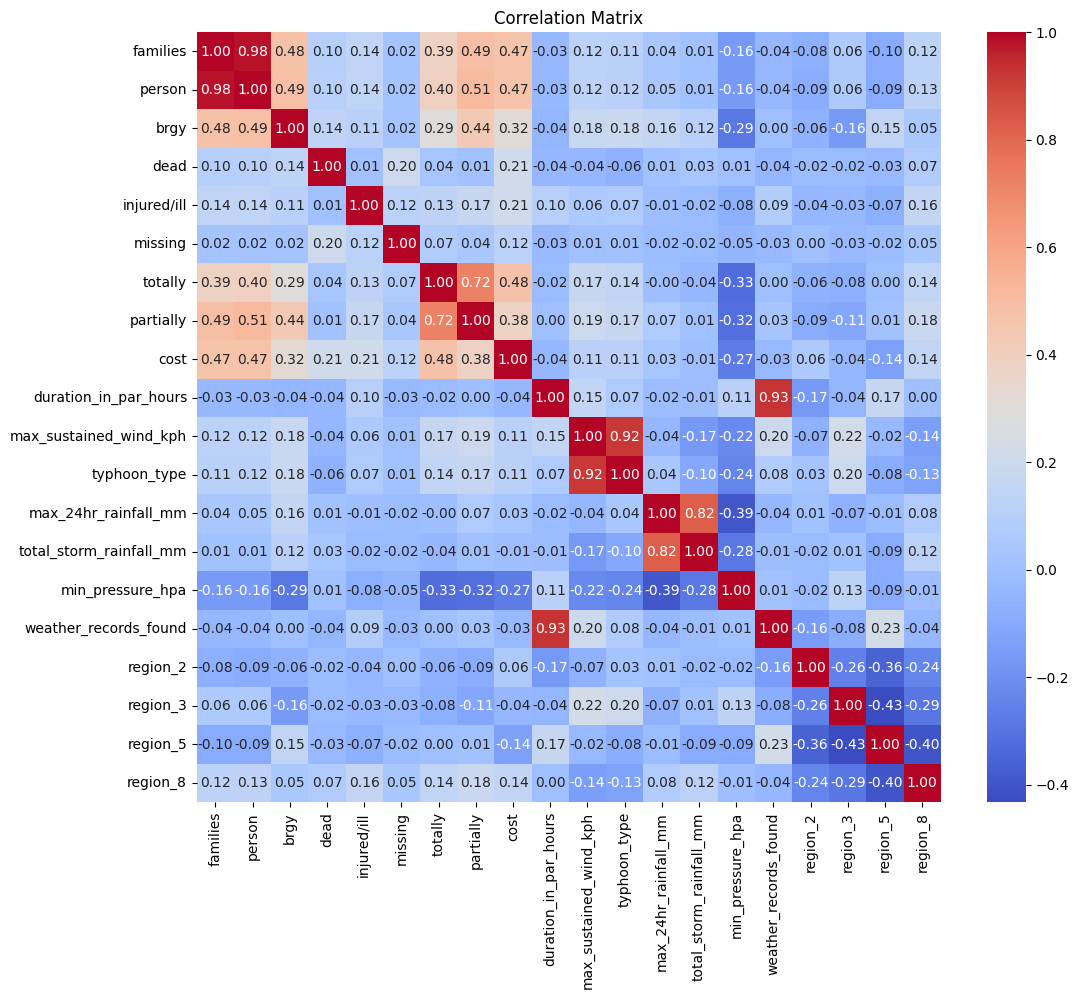

In [12]:
# Calculate the correlation matrix
correlation_matrix = df.corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix")
plt.show()

In [13]:
df.drop(columns=['weather_records_found'], inplace=True)

## PCA Generalization Functions
Functions for performing Principal Component Analysis on the typhoon impact dataset.

In [14]:
def prepare_pca_features(input_dataframe: pd.DataFrame, categorical_columns: list = None) -> tuple:
    """
    Prepare features for PCA by separating numerical and categorical columns.
    
    Parameters:
    -----------
    input_dataframe : pd.DataFrame
        The input dataframe containing features
    categorical_columns : list, optional
        List of categorical column names. If None, auto-detects object dtype columns.
    
    Returns:
    --------
    tuple: (numerical_features_df, categorical_features_df, numerical_column_names)
    """
    if categorical_columns is None:
        categorical_columns = input_dataframe.select_dtypes(include=['object']).columns.tolist()
    
    numerical_column_names = [col for col in input_dataframe.columns if col not in categorical_columns]
    
    numerical_features_df = input_dataframe[numerical_column_names].copy()
    categorical_features_df = input_dataframe[categorical_columns].copy() if categorical_columns else pd.DataFrame()
    
    return numerical_features_df, categorical_features_df, numerical_column_names


def scale_numerical_features(numerical_features_df: pd.DataFrame) -> tuple:
    """
    Scale numerical features using StandardScaler.
    
    Parameters:
    -----------
    numerical_features_df : pd.DataFrame
        DataFrame containing only numerical features
    
    Returns:
    --------
    tuple: (scaled_features_array, fitted_scaler_object)
    """
    feature_scaler_object = StandardScaler()
    scaled_features_array = feature_scaler_object.fit_transform(numerical_features_df)
    
    return scaled_features_array, feature_scaler_object


def perform_pca_analysis(
    scaled_features_array: np.ndarray,
    n_components: int = None,
    variance_threshold: float = 0.95
) -> tuple:
    """
    Perform PCA analysis on scaled features.
    
    Parameters:
    -----------
    scaled_features_array : np.ndarray
        Scaled numerical features array
    n_components : int, optional
        Number of components to keep. If None, uses variance_threshold.
    variance_threshold : float, default=0.95
        Cumulative variance threshold to determine n_components if n_components is None.
    
    Returns:
    --------
    tuple: (pca_transformed_array, fitted_pca_object, explained_variance_ratios)
    """
    # First fit PCA to determine optimal components if not specified
    if n_components is None:
        preliminary_pca_object = PCA()
        preliminary_pca_object.fit(scaled_features_array)
        cumulative_variance_array = np.cumsum(preliminary_pca_object.explained_variance_ratio_)
        n_components = np.argmax(cumulative_variance_array >= variance_threshold) + 1
        del preliminary_pca_object  # Clean up to avoid memory leak
    
    # Perform final PCA with determined number of components
    final_pca_object = PCA(n_components=n_components)
    pca_transformed_array = final_pca_object.fit_transform(scaled_features_array)
    explained_variance_ratios = final_pca_object.explained_variance_ratio_
    
    return pca_transformed_array, final_pca_object, explained_variance_ratios


def create_pca_dataframe(
    pca_transformed_array: np.ndarray,
    n_components: int
) -> pd.DataFrame:
    """
    Create a DataFrame from PCA transformed array with proper column names.
    
    Parameters:
    -----------
    pca_transformed_array : np.ndarray
        Array of PCA transformed features
    n_components : int
        Number of PCA components
    
    Returns:
    --------
    pd.DataFrame: DataFrame with PCA components as columns
    """
    pca_column_names = [f'PC{i+1}' for i in range(n_components)]
    pca_features_df = pd.DataFrame(pca_transformed_array, columns=pca_column_names)
    
    return pca_features_df


def plot_pca_variance_explanation(
    fitted_pca_object: PCA,
    figure_title: str = 'PCA Variance Explanation'
) -> None:
    """
    Plot the explained variance ratio for each PCA component.
    
    Parameters:
    -----------
    fitted_pca_object : PCA
        Fitted PCA object
    figure_title : str
        Title for the plot
    """
    variance_ratios_array = fitted_pca_object.explained_variance_ratio_
    cumulative_variance_array = np.cumsum(variance_ratios_array)
    n_components_count = len(variance_ratios_array)
    
    pca_variance_fig, pca_variance_axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Individual variance plot
    pca_variance_axes[0].bar(range(1, n_components_count + 1), variance_ratios_array, alpha=0.7, color='steelblue')
    pca_variance_axes[0].set_xlabel('Principal Component')
    pca_variance_axes[0].set_ylabel('Explained Variance Ratio')
    pca_variance_axes[0].set_title('Individual Explained Variance')
    pca_variance_axes[0].set_xticks(range(1, n_components_count + 1))
    
    # Cumulative variance plot
    pca_variance_axes[1].plot(range(1, n_components_count + 1), cumulative_variance_array, 'bo-', linewidth=2, markersize=8)
    pca_variance_axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% Threshold')
    pca_variance_axes[1].set_xlabel('Number of Components')
    pca_variance_axes[1].set_ylabel('Cumulative Explained Variance')
    pca_variance_axes[1].set_title('Cumulative Explained Variance')
    pca_variance_axes[1].set_xticks(range(1, n_components_count + 1))
    pca_variance_axes[1].legend()
    pca_variance_axes[1].grid(True, alpha=0.3)
    
    pca_variance_fig.suptitle(figure_title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Clean up
    plt.close(pca_variance_fig)


def get_pca_feature_loadings(
    fitted_pca_object: PCA,
    feature_names_list: list
) -> pd.DataFrame:
    """
    Get the feature loadings (component weights) for each PCA component.
    
    Parameters:
    -----------
    fitted_pca_object : PCA
        Fitted PCA object
    feature_names_list : list
        List of original feature names
    
    Returns:
    --------
    pd.DataFrame: DataFrame with feature loadings for each component
    """
    n_components_count = fitted_pca_object.n_components_
    component_names_list = [f'PC{i+1}' for i in range(n_components_count)]
    
    feature_loadings_df = pd.DataFrame(
        fitted_pca_object.components_.T,
        columns=component_names_list,
        index=feature_names_list
    )
    
    return feature_loadings_df


def run_complete_pca_pipeline(
    input_dataframe: pd.DataFrame,
    n_components: int = None,
    variance_threshold: float = 0.95,
    categorical_columns: list = None,
    show_plots: bool = True,
    return_loadings: bool = True
) -> dict:
    """
    Run the complete PCA pipeline on the input dataframe.
    
    Parameters:
    -----------
    input_dataframe : pd.DataFrame
        Input dataframe with features
    n_components : int, optional
        Number of PCA components. If None, auto-determined by variance_threshold.
    variance_threshold : float, default=0.95
        Cumulative variance threshold for auto-determining n_components
    categorical_columns : list, optional
        List of categorical column names to exclude from PCA
    show_plots : bool, default=True
        Whether to display variance explanation plots
    return_loadings : bool, default=True
        Whether to include feature loadings in the result
    
    Returns:
    --------
    dict: Dictionary containing:
        - 'pca_dataframe': DataFrame with PCA components
        - 'pca_object': Fitted PCA object
        - 'scaler_object': Fitted StandardScaler object
        - 'explained_variance': Array of explained variance ratios
        - 'total_variance_explained': Total variance explained by components
        - 'feature_loadings': DataFrame of feature loadings (if return_loadings=True)
        - 'numerical_features': List of numerical feature names used
    """
    # Step 1: Prepare features
    numerical_features_df, categorical_features_df, numerical_column_names = prepare_pca_features(
        input_dataframe, categorical_columns
    )
    
    print(f"Numerical features for PCA: {len(numerical_column_names)}")
    print(f"Features: {numerical_column_names}")
    
    # Step 2: Scale features
    scaled_features_array, feature_scaler_object = scale_numerical_features(numerical_features_df)
    
    # Step 3: Perform PCA
    pca_transformed_array, fitted_pca_object, explained_variance_ratios = perform_pca_analysis(
        scaled_features_array, n_components, variance_threshold
    )
    
    actual_n_components = fitted_pca_object.n_components_
    total_variance_explained = np.sum(explained_variance_ratios)
    
    print(f"\nPCA Results:")
    print(f"Number of components: {actual_n_components}")
    print(f"Total variance explained: {total_variance_explained:.4f} ({total_variance_explained*100:.2f}%)")
    
    # Step 4: Create PCA DataFrame
    pca_features_df = create_pca_dataframe(pca_transformed_array, actual_n_components)
    
    # Step 5: Plot variance explanation
    if show_plots:
        plot_pca_variance_explanation(fitted_pca_object, 'Typhoon Impact Data - PCA Variance Explanation')
    
    # Prepare result dictionary
    pca_result_dict = {
        'pca_dataframe': pca_features_df,
        'pca_object': fitted_pca_object,
        'scaler_object': feature_scaler_object,
        'explained_variance': explained_variance_ratios,
        'total_variance_explained': total_variance_explained,
        'numerical_features': numerical_column_names
    }
    
    # Step 6: Get feature loadings if requested
    if return_loadings:
        feature_loadings_df = get_pca_feature_loadings(fitted_pca_object, numerical_column_names)
        pca_result_dict['feature_loadings'] = feature_loadings_df
    
    # Clean up intermediate variables
    del scaled_features_array, pca_transformed_array
    
    return pca_result_dict

Numerical features for PCA: 19
Features: ['families', 'person', 'brgy', 'dead', 'injured/ill', 'missing', 'totally', 'partially', 'cost', 'duration_in_par_hours', 'max_sustained_wind_kph', 'typhoon_type', 'max_24hr_rainfall_mm', 'total_storm_rainfall_mm', 'min_pressure_hpa', 'region_2', 'region_3', 'region_5', 'region_8']

PCA Results:
Number of components: 13
Total variance explained: 0.9515 (95.15%)


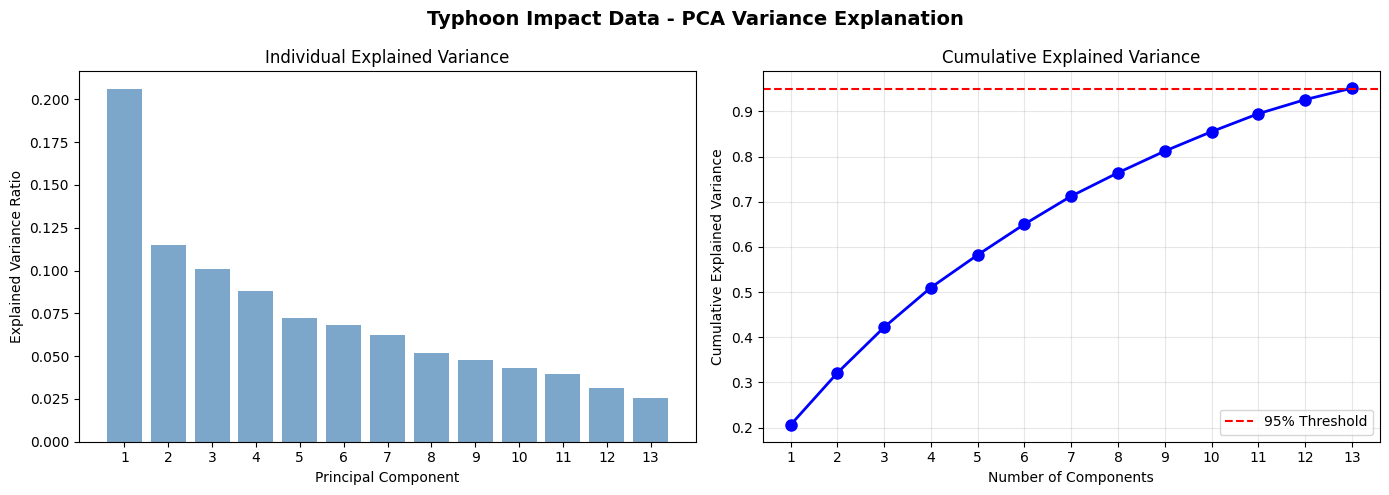

In [15]:
# Run PCA pipeline on typhoon impact data
typhoon_pca_results = run_complete_pca_pipeline(
    input_dataframe=df,
    n_components=None,  # Auto-determine based on variance threshold
    variance_threshold=0.95,
    categorical_columns=None,  # Include all columns (typhoon_type is now ordinal encoded)
    show_plots=True,
    return_loadings=True
)

In [16]:
# Access PCA results
typhoon_pca_df = typhoon_pca_results['pca_dataframe']

# Display explained variance information
print("=" * 60)
print("PCA EXPLAINED VARIANCE SUMMARY")
print("=" * 60)
print(f"Total samples: {len(typhoon_pca_df)}")
print(f"Number of PCA components: {typhoon_pca_df.shape[1]}")
print(f"Total variance explained: {typhoon_pca_results['total_variance_explained']*100:.2f}%")
print("\nVariance explained per component:")
for i, var in enumerate(typhoon_pca_results['explained_variance']):
    print(f"  PC{i+1}: {var*100:.2f}%")
print("=" * 60)

PCA EXPLAINED VARIANCE SUMMARY
Total samples: 1776
Number of PCA components: 13
Total variance explained: 95.15%

Variance explained per component:
  PC1: 20.61%
  PC2: 11.51%
  PC3: 10.11%
  PC4: 8.79%
  PC5: 7.23%
  PC6: 6.80%
  PC7: 6.21%
  PC8: 5.17%
  PC9: 4.79%
  PC10: 4.30%
  PC11: 3.98%
  PC12: 3.12%
  PC13: 2.53%


## Plotting 2D and 3D

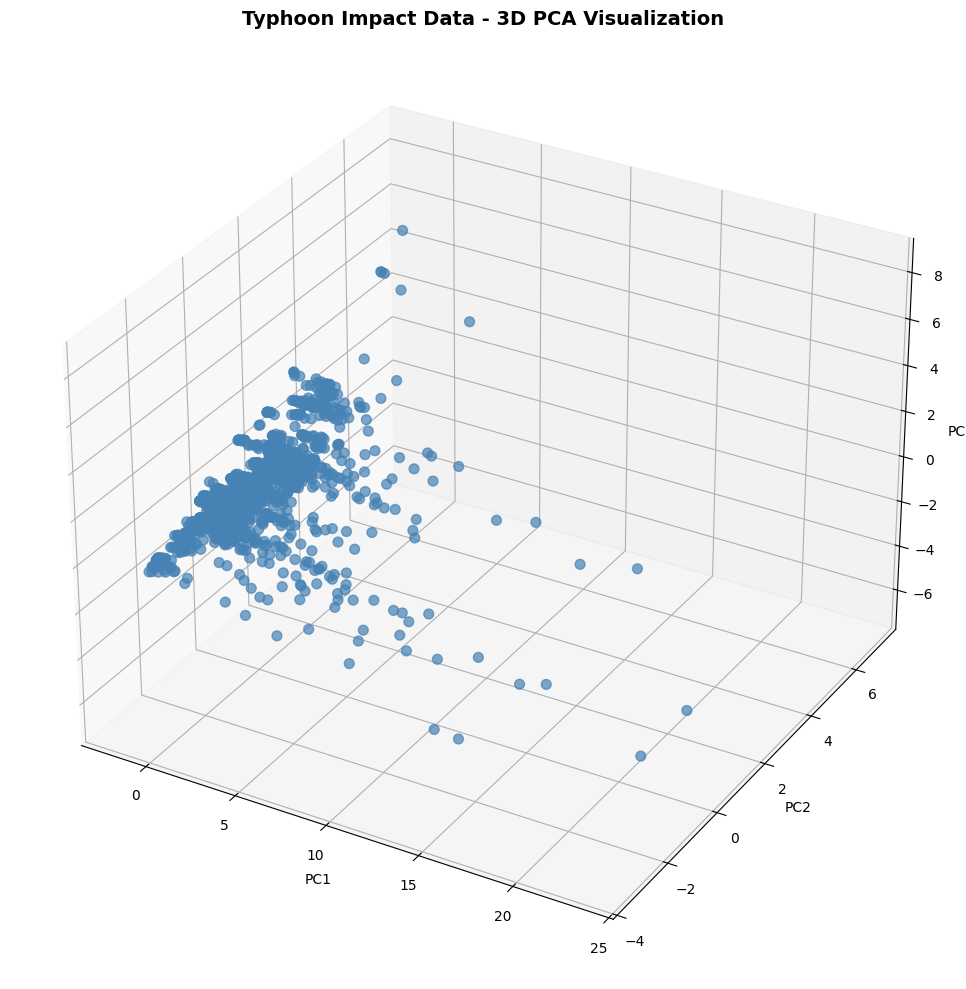

In [17]:
# 3D PCA Visualization
from mpl_toolkits.mplot3d import Axes3D

def plot_pca_3d(
    pca_dataframe: pd.DataFrame,
    cluster_labels: np.ndarray = None,
    figure_title: str = 'PCA 3D Visualization'
) -> None:
    """
    Create a 3D scatter plot of the first 3 PCA components.
    
    Parameters:
    -----------
    pca_dataframe : pd.DataFrame
        DataFrame containing PCA components (PC1, PC2, PC3)
    cluster_labels : np.ndarray, optional
        Cluster labels for coloring points
    figure_title : str
        Title for the 3D plot
    """
    pca_3d_fig = plt.figure(figsize=(12, 10))
    pca_3d_ax = pca_3d_fig.add_subplot(111, projection='3d')
    
    pc1_values = pca_dataframe['PC1'].values
    pc2_values = pca_dataframe['PC2'].values
    pc3_values = pca_dataframe['PC3'].values
    
    if cluster_labels is not None:
        scatter_plot = pca_3d_ax.scatter(
            pc1_values, pc2_values, pc3_values,
            c=cluster_labels, cmap='viridis', s=50, alpha=0.7
        )
        pca_3d_fig.colorbar(scatter_plot, ax=pca_3d_ax, label='Cluster')
    else:
        pca_3d_ax.scatter(
            pc1_values, pc2_values, pc3_values,
            c='steelblue', s=50, alpha=0.7
        )
    
    pca_3d_ax.set_xlabel('PC1')
    pca_3d_ax.set_ylabel('PC2')
    pca_3d_ax.set_zlabel('PC3')
    pca_3d_ax.set_title(figure_title, fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    plt.close(pca_3d_fig)

# Plot 3D PCA visualization
plot_pca_3d(typhoon_pca_df, figure_title='Typhoon Impact Data - 3D PCA Visualization')

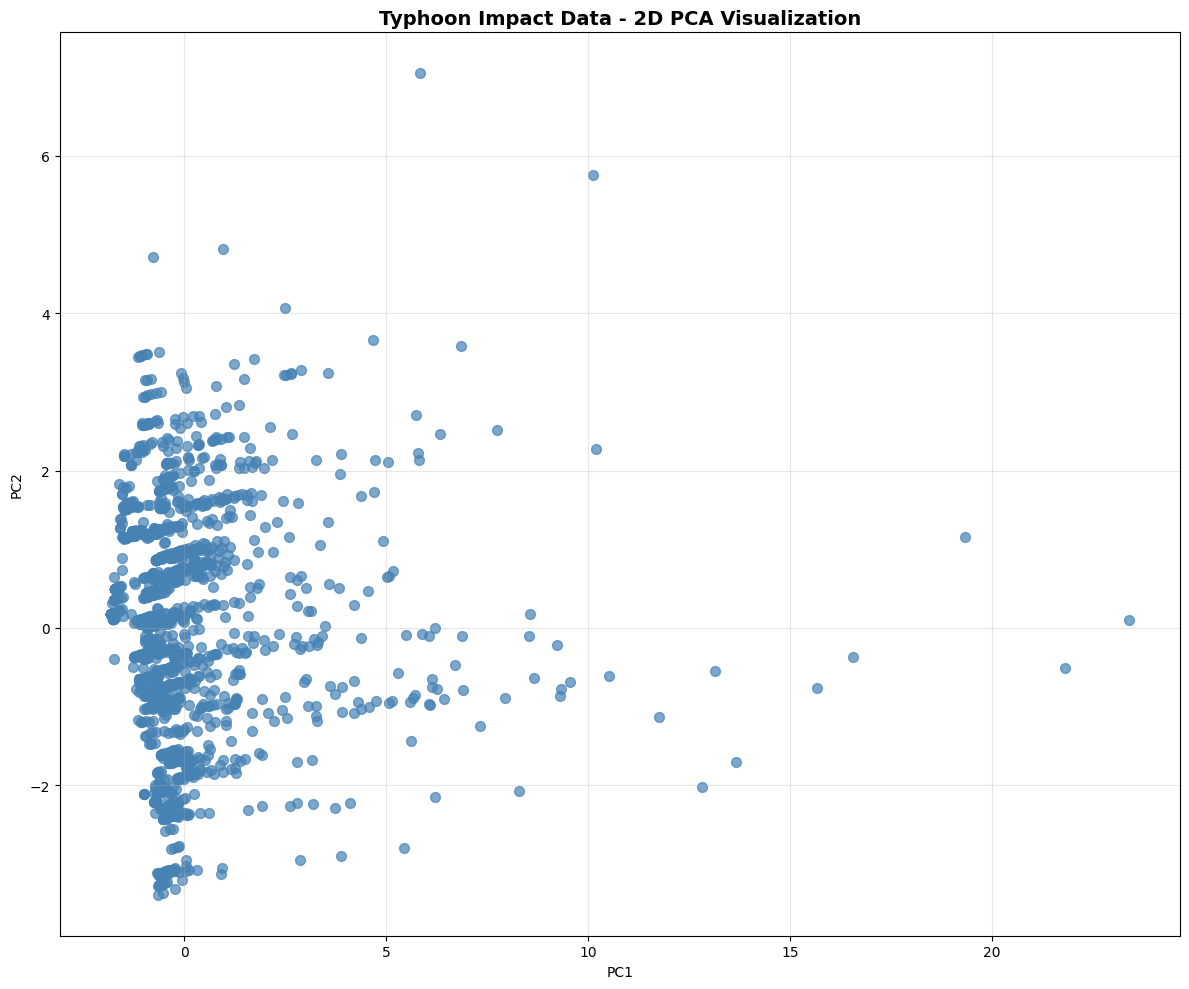

In [18]:
# 2D PCA Visualization
def plot_pca_2d(
    pca_dataframe: pd.DataFrame,
    cluster_labels: np.ndarray = None,
    figure_title: str = 'PCA 2D Visualization'
) -> None:
    """
    Create a 2D scatter plot of the first 2 PCA components.
    
    Parameters:
    -----------
    pca_dataframe : pd.DataFrame
        DataFrame containing PCA components (PC1, PC2)
    cluster_labels : np.ndarray, optional
        Cluster labels for coloring points
    figure_title : str
        Title for the 2D plot
    """
    pca_2d_fig, pca_2d_ax = plt.subplots(figsize=(12, 10))
    
    pc1_values = pca_dataframe['PC1'].values
    pc2_values = pca_dataframe['PC2'].values
    
    if cluster_labels is not None:
        scatter_plot_2d = pca_2d_ax.scatter(
            pc1_values, pc2_values,
            c=cluster_labels, cmap='viridis', s=50, alpha=0.7
        )
        pca_2d_fig.colorbar(scatter_plot_2d, ax=pca_2d_ax, label='Cluster')
    else:
        pca_2d_ax.scatter(
            pc1_values, pc2_values,
            c='steelblue', s=50, alpha=0.7
        )
    
    pca_2d_ax.set_xlabel('PC1')
    pca_2d_ax.set_ylabel('PC2')
    pca_2d_ax.set_title(figure_title, fontsize=14, fontweight='bold')
    pca_2d_ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    plt.close(pca_2d_fig)

# Plot 2D PCA visualization
plot_pca_2d(typhoon_pca_df, figure_title='Typhoon Impact Data - 2D PCA Visualization')

In [19]:
df.head()

,families,person,brgy,dead,injured/ill,missing,totally,partially,cost,duration_in_par_hours,max_sustained_wind_kph,typhoon_type,max_24hr_rainfall_mm,total_storm_rainfall_mm,min_pressure_hpa,region_2,region_3,region_5,region_8
0,3608,11120,6,0,0,0,0,0,2646179.36,133.0,195,4,25.6,39.00,977.1,1,0,0,0
1,968,3028,5,0,0,0,0,0,494592.00,133.0,195,4,20.3,32.71,1000.5,1,0,0,0
2,444,1532,4,0,0,0,0,0,227328.00,133.0,195,4,25.6,39.00,977.1,1,0,0,0
3,575,1792,4,0,0,0,0,0,291082.96,133.0,195,4,25.6,39.00,977.1,1,0,0,0
4,575,1955,6,0,0,0,0,0,296521.75,133.0,195,4,25.6,39.00,977.1,1,0,0,0


## Standard Scaling of Sample Data

In [20]:
# Initialize StandardScaler
scaler = StandardScaler()

df_clean = df.copy()

# Fit and transform the data
df_scaled = scaler.fit_transform(df_clean)

# Convert back to DataFrame with original column names
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)

print("Original data (first 5 rows):")
display(df.head())
print("\nScaled data (first 5 rows):")
display(df_scaled.head())

Original data (first 5 rows):


,families,person,brgy,dead,injured/ill,missing,totally,partially,cost,duration_in_par_hours,max_sustained_wind_kph,typhoon_type,max_24hr_rainfall_mm,total_storm_rainfall_mm,min_pressure_hpa,region_2,region_3,region_5,region_8
0,3608,11120,6,0,0,0,0,0,2646179.36,133.0,195,4,25.6,39.00,977.1,1,0,0,0
1,968,3028,5,0,0,0,0,0,494592.00,133.0,195,4,20.3,32.71,1000.5,1,0,0,0
2,444,1532,4,0,0,0,0,0,227328.00,133.0,195,4,25.6,39.00,977.1,1,0,0,0
3,575,1792,4,0,0,0,0,0,291082.96,133.0,195,4,25.6,39.00,977.1,1,0,0,0
4,575,1955,6,0,0,0,0,0,296521.75,133.0,195,4,25.6,39.00,977.1,1,0,0,0



Scaled data (first 5 rows):


,families,person,brgy,dead,injured/ill,missing,totally,partially,cost,duration_in_par_hours,max_sustained_wind_kph,typhoon_type,max_24hr_rainfall_mm,total_storm_rainfall_mm,min_pressure_hpa,region_2,region_3,region_5,region_8
0,0.627959,0.432912,-0.245512,-0.04519,-0.121532,-0.050655,-0.140446,-0.198449,1.833588,0.422971,1.093216,1.133352,-1.099347,-1.169851,-1.861117,2.161972,-0.557406,-0.776459,-0.51649
1,-0.096344,-0.147600,-0.332928,-0.04519,-0.121532,-0.050655,-0.140446,-0.198449,0.147222,0.422971,1.093216,1.133352,-1.173803,-1.226523,0.466233,2.161972,-0.557406,-0.776459,-0.51649
2,-0.240108,-0.254921,-0.420344,-0.04519,-0.121532,-0.050655,-0.140446,-0.198449,-0.062254,0.422971,1.093216,1.133352,-1.099347,-1.169851,-1.861117,2.161972,-0.557406,-0.776459,-0.51649
3,-0.204167,-0.236269,-0.420344,-0.04519,-0.121532,-0.050655,-0.140446,-0.198449,-0.012284,0.422971,1.093216,1.133352,-1.099347,-1.169851,-1.861117,2.161972,-0.557406,-0.776459,-0.51649
4,-0.204167,-0.224576,-0.245512,-0.04519,-0.121532,-0.050655,-0.140446,-0.198449,-0.008021,0.422971,1.093216,1.133352,-1.099347,-1.169851,-1.861117,2.161972,-0.557406,-0.776459,-0.51649


In [21]:
# DBSCAN with Optuna Optimization (strictly 3 clusters)
from sklearn.cluster import DBSCAN
import numpy as np

def optuna_dbscan_objective(trial, data):
    """Optuna objective for DBSCAN optimization with strict 3 clusters constraint."""
    eps = trial.suggest_float('eps', 0.5, 10.0)
    min_samples = trial.suggest_int('min_samples', 2, 20)
    
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(data)
    
    # Count clusters (excluding noise points labeled as -1)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    # Strictly enforce 3 clusters - return very low score otherwise
    if n_clusters != 3:
        return -1.0
    
    # Filter out noise points for metric calculation
    valid_mask = labels >= 0
    valid_data = data[valid_mask]
    valid_labels = labels[valid_mask]
    
    # Penalize if too many noise points (more than 10%)
    noise_ratio = np.sum(labels == -1) / len(labels)
    if noise_ratio > 0.10:
        return -1.0
    
    if len(np.unique(valid_labels)) < 2:
        return -1.0
    
    # Return silhouette score as the objective
    return silhouette_score(valid_data, valid_labels)

# Run Optuna optimization for DBSCAN
print("Running Optuna optimization for DBSCAN (strictly 3 clusters)...")
print("This may take a moment as we search for parameters that produce exactly 3 clusters.\n")

dbscan_study = optuna.create_study(direction='maximize', study_name='dbscan_3clusters_optimization')
dbscan_study.optimize(
    lambda trial: optuna_dbscan_objective(trial, df_scaled.values),
    n_trials=200,  # More trials to find valid 3-cluster configurations
    show_progress_bar=True
)

# Get best parameters
best_params = dbscan_study.best_params
best_score = dbscan_study.best_value

print(f"\nBest parameters found:")
print(f"  - eps: {best_params['eps']:.4f}")
print(f"  - min_samples: {best_params['min_samples']}")
print(f"  - Best Silhouette Score: {best_score:.4f}")

# Train final DBSCAN model with best parameters
dbscan = DBSCAN(eps=best_params['eps'], min_samples=best_params['min_samples'])
dbscan_labels = dbscan.fit_predict(df_scaled)

# Verify cluster count
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"\nFinal DBSCAN Results:")
print(f"  - Number of clusters: {n_clusters}")
print(f"  - Noise points: {n_noise} ({n_noise/len(dbscan_labels)*100:.2f}%)")

# Add cluster labels to dataframe
df['dbscan_cluster'] = dbscan_labels

# Calculate clustering metrics (excluding noise)
valid_mask = dbscan_labels >= 0
if np.sum(valid_mask) > 0 and len(np.unique(dbscan_labels[valid_mask])) >= 2:
    silhouette = silhouette_score(df_scaled.values[valid_mask], dbscan_labels[valid_mask])
    calinski = calinski_harabasz_score(df_scaled.values[valid_mask], dbscan_labels[valid_mask])
    davies = davies_bouldin_score(df_scaled.values[valid_mask], dbscan_labels[valid_mask])
    
    print(f"\nClustering Metrics (excluding noise points):")
    print(f"  - Silhouette Score: {silhouette:.4f}")
    print(f"  - Calinski-Harabasz Index: {calinski:.4f}")
    print(f"  - Davies-Bouldin Index: {davies:.4f}")

[I 2025-12-10 22:24:19,164] A new study created in memory with name: dbscan_3clusters_optimization


Running Optuna optimization for DBSCAN (strictly 3 clusters)...
This may take a moment as we search for parameters that produce exactly 3 clusters.



  0%|          | 0/200 [00:00<?, ?it/s]

[I 2025-12-10 22:24:19,771] Trial 0 finished with value: -1.0 and parameters: {'eps': 2.5559989527102163, 'min_samples': 7}. Best is trial 0 with value: -1.0.
[I 2025-12-10 22:24:19,916] Trial 1 finished with value: -1.0 and parameters: {'eps': 5.611061694366213, 'min_samples': 12}. Best is trial 0 with value: -1.0.
[I 2025-12-10 22:24:20,115] Trial 2 finished with value: -1.0 and parameters: {'eps': 7.65951720492288, 'min_samples': 16}. Best is trial 0 with value: -1.0.
[I 2025-12-10 22:24:20,452] Trial 3 finished with value: -1.0 and parameters: {'eps': 9.563203156331028, 'min_samples': 14}. Best is trial 0 with value: -1.0.
[I 2025-12-10 22:24:21,064] Trial 4 finished with value: -1.0 and parameters: {'eps': 5.216834932683866, 'min_samples': 5}. Best is trial 0 with value: -1.0.
[I 2025-12-10 22:24:21,297] Trial 5 finished with value: -1.0 and parameters: {'eps': 7.251709219664966, 'min_samples': 20}. Best is trial 0 with value: -1.0.
[I 2025-12-10 22:24:21,618] Trial 6 finished wit

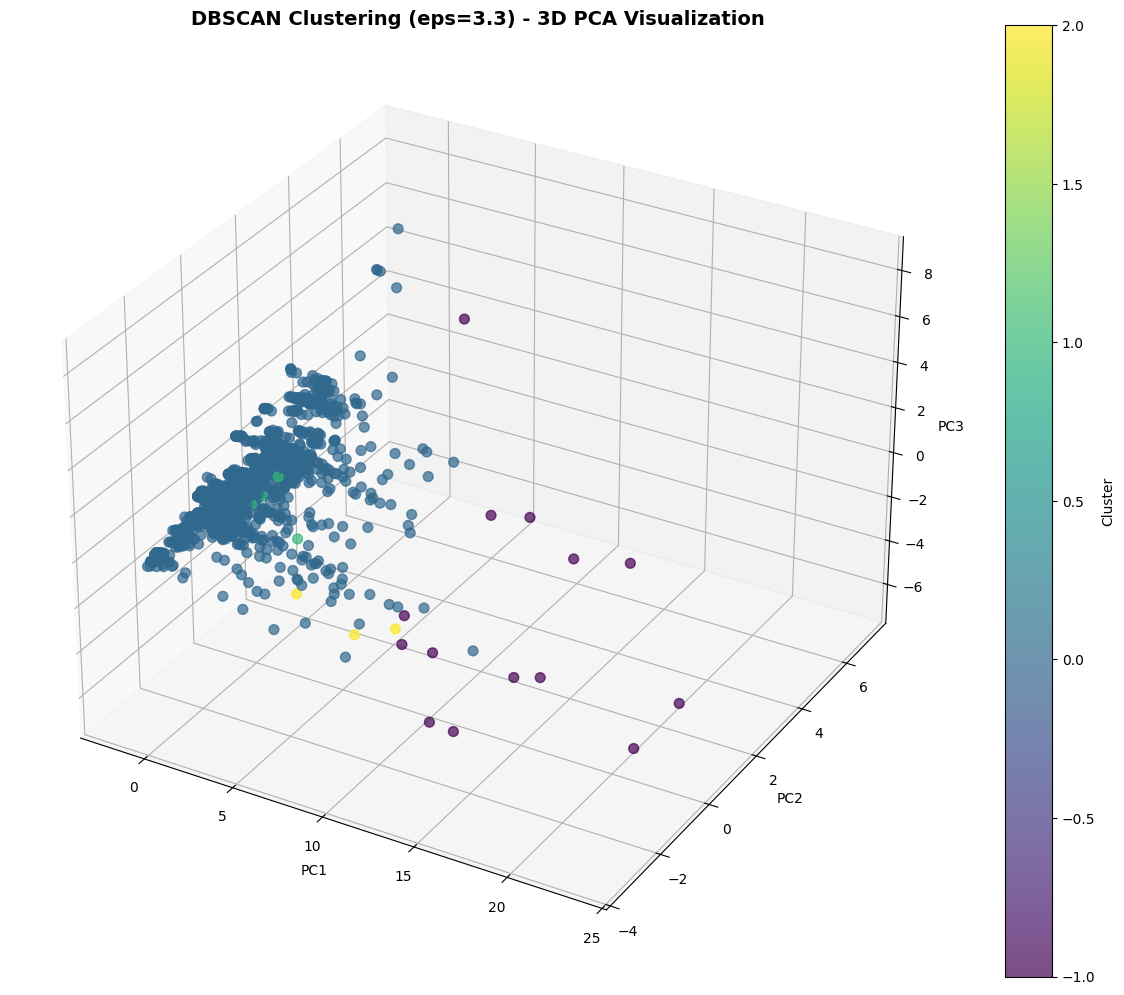

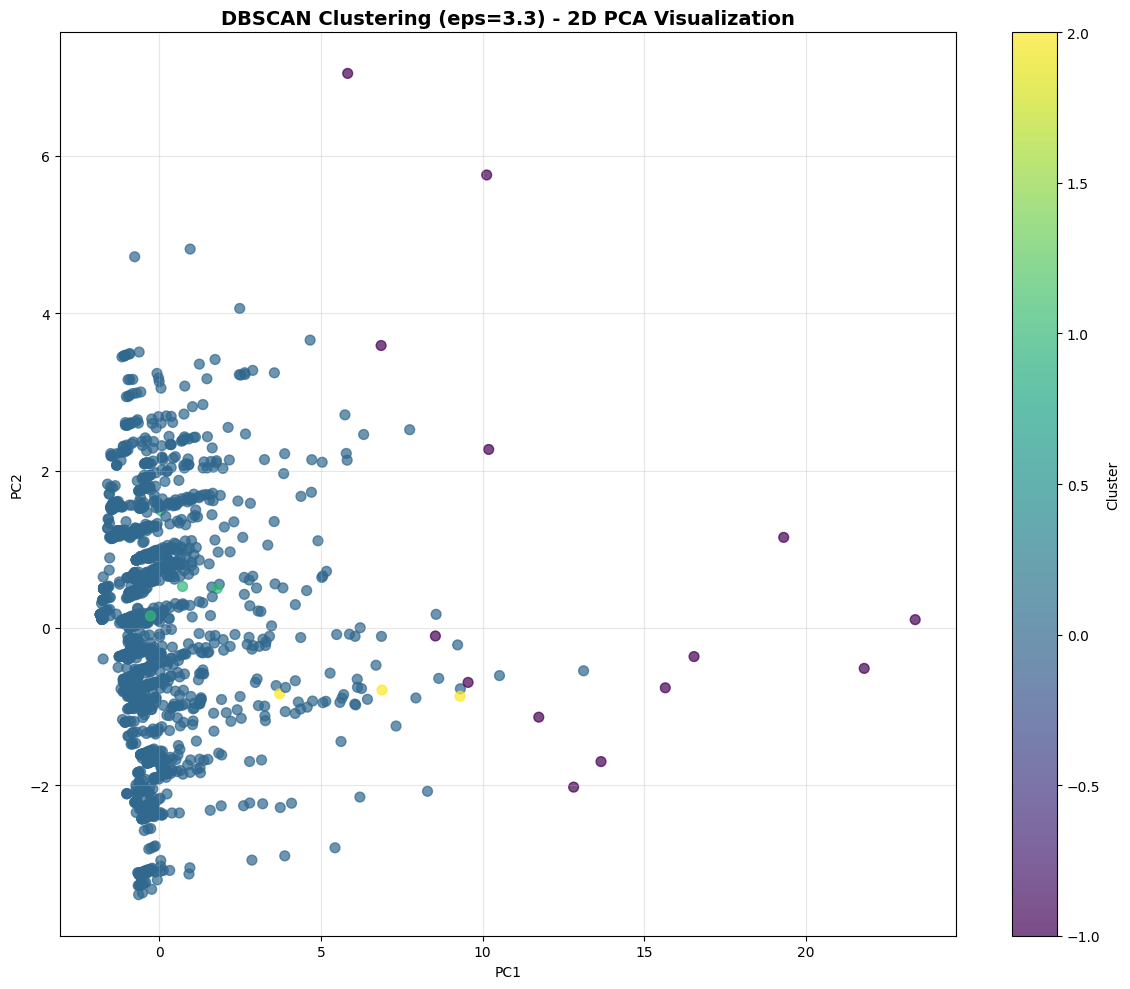


DBSCAN CLUSTERING RESULTS (eps=3.3) - ORIGINAL DATA

CLUSTER 0
Number of records: 1754


,Typhoon Name,Year,Region,Province,City/Municipality,Families,Person,Brgy,Dead,Injured/Ill,...,PAR_END,Duration_in_PAR_Hours,Max_Sustained_Wind_kph,Typhoon_Type,Max_24hr_Rainfall_mm,Total_Storm_Rainfall_mm,Min_Pressure_hPa,Weather_Station_Mapped,Weather_Records_Found,Weather_Days_Covered
0,BETTY,2023,2,BATANES,BASCO,3608,11120,6,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6
1,BETTY,2023,2,BATANES,ITBAYAT,968,3028,5,0,0,...,6/1/2023,133.0,195,STY,20.3,32.71,1000.5,1,6,6
2,BETTY,2023,2,BATANES,IVANA,444,1532,4,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6
3,BETTY,2023,2,BATANES,MAHATAO,575,1792,4,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6
4,BETTY,2023,2,BATANES,SABTANG,575,1955,6,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6
5,BETTY,2023,2,BATANES,UYUGAN,433,1464,4,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6
6,HENRY,2022,2,BATANES,BASCO,2,10,1,0,0,...,9/4/2022,80.2,195,STY,85.4,139.60,994.2,1,5,5
7,JENNY,2023,2,BATANES,BASCO,1,1,1,0,0,...,10/6/2023,146.7,175,TY,134.0,224.20,998.9,1,8,8
8,JENNY,2023,2,BATANES,ITBAYAT,6,20,2,0,0,...,10/6/2023,146.7,175,TY,273.0,355.80,1000.6,1,8,8
9,JENNY,2023,2,BATANES,SABTANG,0,139,4,0,0,...,10/6/2023,146.7,175,TY,134.0,224.20,998.9,1,8,8



CLUSTER 1
Number of records: 5


,Typhoon Name,Year,Region,Province,City/Municipality,Families,Person,Brgy,Dead,Injured/Ill,...,PAR_END,Duration_in_PAR_Hours,Max_Sustained_Wind_kph,Typhoon_Type,Max_24hr_Rainfall_mm,Total_Storm_Rainfall_mm,Min_Pressure_hPa,Weather_Station_Mapped,Weather_Records_Found,Weather_Days_Covered
81,MARING,2021,2,CAGAYAN,SANTA ANA,19,88,6,1,0,...,10/12/2021,118.0,100,STS,138.4,227.31,981.4,1,6,6
264,PAENG,2022,2,NUEVA VIZCAYA,ARITAO,38,142,4,1,1,...,10/31/2022,124.7,110,STS,97.4,145.40,994.1,1,6,6
1173,QUINTA,2020,5,CATANDUANES,GIGMOTO,957,3509,8,3,0,...,10/27/2020,71.0,150,TY,108.0,197.20,978.4,1,5,5
1235,JOLINA,2021,5,MASBATE,BALUD,0,0,0,3,1,...,9/9/2021,103.0,120,TY,95.6,143.61,997.2,1,4,4
1465,JOLINA,2021,8,EASTERN SAMAR,LLORENTE,5963,21306,1,0,0,...,9/9/2021,103.0,120,TY,99.5,101.50,1002.9,1,4,4



CLUSTER 2
Number of records: 3


,Typhoon Name,Year,Region,Province,City/Municipality,Families,Person,Brgy,Dead,Injured/Ill,...,PAR_END,Duration_in_PAR_Hours,Max_Sustained_Wind_kph,Typhoon_Type,Max_24hr_Rainfall_mm,Total_Storm_Rainfall_mm,Min_Pressure_hPa,Weather_Station_Mapped,Weather_Records_Found,Weather_Days_Covered
1446,AMBO,2020,8,EASTERN SAMAR,ARTECHE,4603,18519,20,0,56,...,5/17/2020,198.0,155,TY,19.2,70.11,999.5,1,8,8
1450,AMBO,2020,8,EASTERN SAMAR,JIPAPAD,2387,8655,13,0,42,...,5/17/2020,198.0,155,TY,19.2,70.11,999.5,1,8,8
1746,ODETTE,2021,8,SOUTHERN LEYTE,MACROHON,8007,29532,30,1,47,...,12/18/2021,91.0,195,STY,24.2,25.00,975.2,1,5,5



NOISE POINTS (Cluster -1)
Number of records: 14


,Typhoon Name,Year,Region,Province,City/Municipality,Families,Person,Brgy,Dead,Injured/Ill,...,PAR_END,Duration_in_PAR_Hours,Max_Sustained_Wind_kph,Typhoon_Type,Max_24hr_Rainfall_mm,Total_Storm_Rainfall_mm,Min_Pressure_hPa,Weather_Station_Mapped,Weather_Records_Found,Weather_Days_Covered
10,KIKO,2021,2,BATANES,BASCO,3043,10656,6,0,0,...,9/12/2021,116.0,215,STY,420.7,604.9,927.9,1,6,6
462,KARDING,2022,3,BULACAN,SAN MIGUEL,52600,191170,9,5,1,...,9/26/2022,114.0,195,STY,55.8,73.3,996.4,1,5,5
510,KARDING,2022,3,NUEVA ECIJA,CABANATUAN CITY,60550,195016,18,0,4,...,9/26/2022,114.0,195,STY,55.8,73.3,996.4,1,5,5
842,ROLLY,2020,5,ALBAY,TABACO CITY,38967,146134,47,0,0,...,11/3/2020,122.0,225,STY,166.7,287.9,981.0,1,6,6
1190,ROLLY,2020,5,CATANDUANES,VIRAC,22856,94356,63,0,0,...,11/3/2020,122.0,225,STY,238.0,245.8,924.9,1,6,6
1517,AGATON,2022,8,LEYTE,ABUYOG,18957,68354,63,55,0,...,4/12/2022,78.0,75,TS,148.8,305.4,1001.2,1,4,4
1523,AGATON,2022,8,LEYTE,BAYBAY,4184,20917,48,95,0,...,4/12/2022,78.0,75,TS,148.8,305.4,1001.2,1,4,4
1557,ODETTE,2021,8,LEYTE,BATO,10410,48612,9,0,0,...,12/18/2021,91.0,195,STY,24.2,25.0,975.2,1,5,5
1558,ODETTE,2021,8,LEYTE,BAYBAY,33387,125457,92,0,0,...,12/18/2021,91.0,195,STY,24.2,25.0,975.2,1,5,5
1560,ODETTE,2021,8,LEYTE,HILONGOS,19133,61482,51,0,0,...,12/18/2021,91.0,195,STY,24.2,25.0,975.2,1,5,5



CLUSTER SUMMARY
Noise: 14 records (0.79%)
Cluster 0: 1754 records (98.76%)
Cluster 1: 5 records (0.28%)
Cluster 2: 3 records (0.17%)


In [22]:
# 3D visualization of DBSCAN clusters
plot_pca_3d(
    pca_dataframe=typhoon_pca_df,
    cluster_labels=dbscan_labels,
    figure_title='DBSCAN Clustering (eps=3.3) - 3D PCA Visualization'
)

# 2D visualization of DBSCAN clusters
plot_pca_2d(
    pca_dataframe=typhoon_pca_df,
    cluster_labels=dbscan_labels,
    figure_title='DBSCAN Clustering (eps=3.3) - 2D PCA Visualization'
)

# Load original data for readable representation
original_df = pd.read_csv('data/typhoon_impact_with_extreme_weather.csv')

# Add cluster labels to original data
original_df['dbscan_cluster'] = dbscan_labels

# Display data for each cluster (excluding noise points -1, showing only clusters 0, 1, 2)
print("\n" + "=" * 80)
print("DBSCAN CLUSTERING RESULTS (eps=3.3) - ORIGINAL DATA")
print("=" * 80)

for cluster_id in [0, 1, 2]:
    cluster_data = original_df[original_df['dbscan_cluster'] == cluster_id]
    
    print("\n" + "=" * 80)
    print(f"CLUSTER {cluster_id}")
    print(f"Number of records: {len(cluster_data)}")
    print("=" * 80)
    display(cluster_data.drop(columns=['dbscan_cluster']).head(10))

# Show noise points separately
noise_data = original_df[original_df['dbscan_cluster'] == -1]
print("\n" + "=" * 80)
print(f"NOISE POINTS (Cluster -1)")
print(f"Number of records: {len(noise_data)}")
print("=" * 80)
display(noise_data.drop(columns=['dbscan_cluster']).head(10))

# Summary statistics for each cluster
print("\n" + "=" * 80)
print("CLUSTER SUMMARY")
print("=" * 80)
for cluster_id in [-1, 0, 1, 2]:
    cluster_name = f"Cluster {cluster_id}" if cluster_id != -1 else "Noise"
    count = len(original_df[original_df['dbscan_cluster'] == cluster_id])
    percentage = (count / len(original_df)) * 100
    print(f"{cluster_name}: {count} records ({percentage:.2f}%)")